In [ ]:
!python --version

Python 3.8.10


In [ ]:
!pip uninstall -y gower
!pip install gower --no-cache-dir --upgrade


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import gower
from sklearn_extra.cluster import KMedoids
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("simulated_clickstream_dataset.csv")
print("Dataset Shape:", df.shape)

Dataset Shape: (2000, 9)


In [ ]:
df.head()

,Device,TrafficSource,PastVisits,TotalPagesViewed,TimePerPage_sec,VisitDuration_min,CartOpened,PurchaseMade,Revenue
0,Mobile,Shopping Site,4,3,13.25,6.74,0,0,0.0
1,Desktop,Referral,2,4,15.72,11.19,0,0,0.0
2,Mobile,Search,1,4,52.86,8.30,0,0,0.0
3,Mobile,Referral,0,11,49.53,4.00,0,0,0.0
4,Mobile,Shopping Site,3,28,37.82,10.13,0,0,0.0


In [ ]:
df.dtypes

Device               category
TrafficSource        category
PastVisits              int64
TotalPagesViewed        int64
TimePerPage_sec       float64
VisitDuration_min     float64
CartOpened              int64
PurchaseMade            int64
Revenue               float64
dtype: object

In [ ]:
# Separate categorical & numerical
cat_cols = ["Device", "TrafficSource"]
num_cols = ["PastVisits", "TotalPagesViewed", "TimePerPage_sec",
            "VisitDuration_min", "CartOpened", "PurchaseMade", "Revenue"]

for col in cat_cols:
    df[col] = df[col].astype("category")

In [ ]:
# Convert categorical columns to string type
for col in cat_cols:
    df[col] = df[col].astype(str)

# Compute Gower distance
gower_dist = gower.gower_matrix(df[cat_cols + num_cols])


In [ ]:
# Try 6 clusters (as in paper)
kmedoids = KMedoids(n_clusters=6, metric="precomputed", random_state=42)
df["Cluster"] = kmedoids.fit_predict(gower_dist)

In [ ]:
# 6. Evaluate Clustering with Silhouette Score
sil_score = silhouette_score(gower_dist, df["Cluster"], metric="precomputed")
print("Silhouette Score:", sil_score)

Silhouette Score: 0.07252393


In [ ]:
print(df["Cluster"].value_counts())

3    451
0    434
1    333
5    283
2    260
4    239
Name: Cluster, dtype: int64


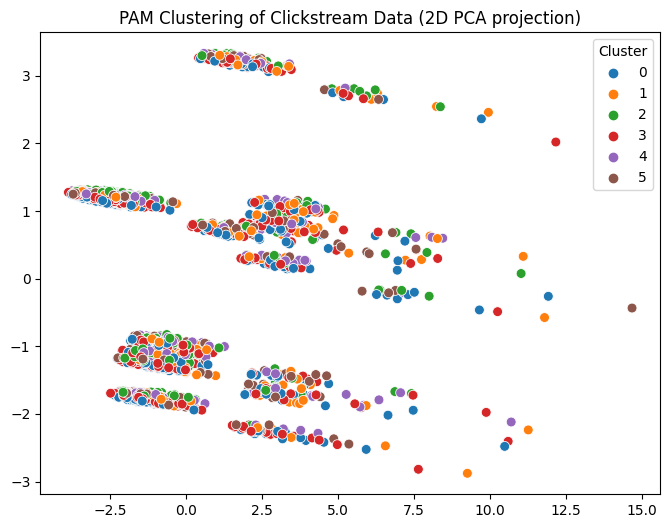

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(gower_dist)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_reduced[:,0], y=X_reduced[:,1], hue=df["Cluster"], palette="tab10", s=50)
plt.title("PAM Clustering of Clickstream Data (2D PCA projection)")
plt.show()

In [ ]:
# Map cluster numbers to descriptive names
cluster_names = {
    0: "Mobile Window Shopping ",
    1: "Enticed to Buy ",
    2: "Examining an Offer ",
    3: "Online Window Shopping ",
    4: "Visiting with a Purpose ",
    5: "Impulsive Trying "
}

# Example: print name of cluster 0
print("Cluster 0:", cluster_names[0])

# Example: map your DataFrame clusters to names
df["Cluster_Name"] = df["Cluster"].map(cluster_names)

# Display counts with names
counts = df["Cluster"].value_counts().reindex(cluster_names.keys(), fill_value=0)
counts.index = counts.index.map(cluster_names)
print(counts)


Cluster 0: Mobile Window Shopping 
Mobile Window Shopping      434
Enticed to Buy              333
Examining an Offer          260
Online Window Shopping      451
Visiting with a Purpose     239
Impulsive Trying            283
Name: Cluster, dtype: int64


In [ ]:
df.to_csv("simulated_clickstream_with_clusters.csv", index=False)
print("✅ New dataset saved with cluster labels!")

NameError: name 'df' is not defined

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Load dataset with clusters (output column = Cluster)
df = pd.read_csv("simulated_clickstream_with_clusters.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (2000, 10)


,Device,TrafficSource,PastVisits,TotalPagesViewed,TimePerPage_sec,VisitDuration_min,CartOpened,PurchaseMade,Revenue,Cluster
0,Mobile,Shopping Site,4,3,13.25,6.74,0,0,0.0,1
1,Desktop,Referral,2,4,15.72,11.19,0,0,0.0,2
2,Mobile,Search,1,4,52.86,8.30,0,0,0.0,0
3,Mobile,Referral,0,11,49.53,4.00,0,0,0.0,0
4,Mobile,Shopping Site,3,28,37.82,10.13,0,0,0.0,5


In [ ]:
# Encode categorical features
df_encoded = pd.get_dummies(df.drop("Cluster", axis=1), drop_first=True)
X = df_encoded
y = df["Cluster"]

In [ ]:
import joblib
# Save column names
joblib.dump(X.columns, "xtrain_columns.pkl")

['xtrain_columns.pkl']

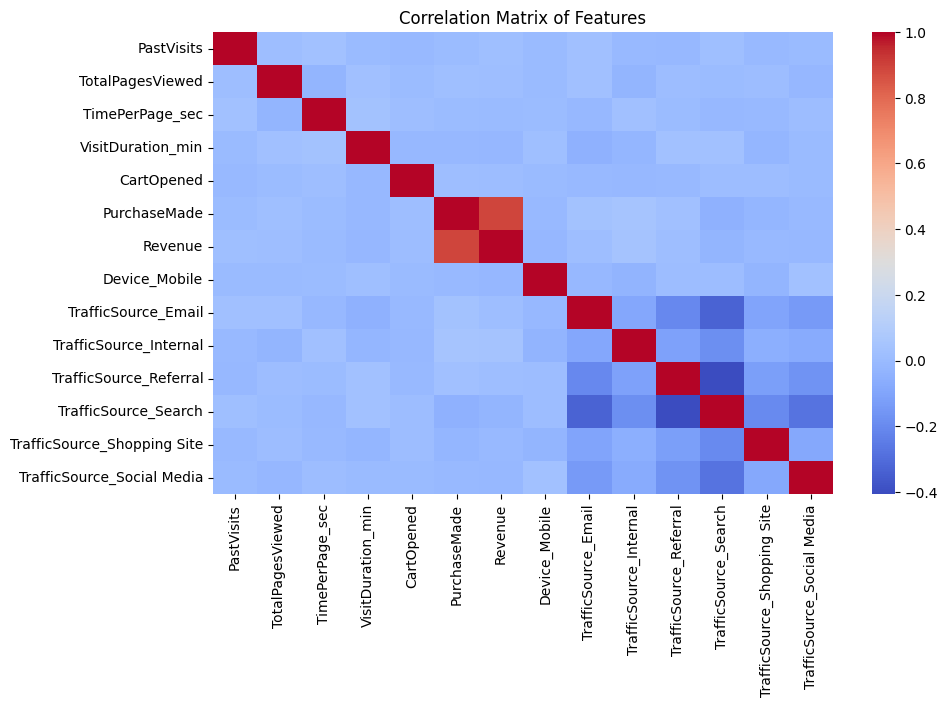

In [ ]:
# Correlation Matrix (numerical features only)
plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation Matrix of Features")
plt.show()

In [ ]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


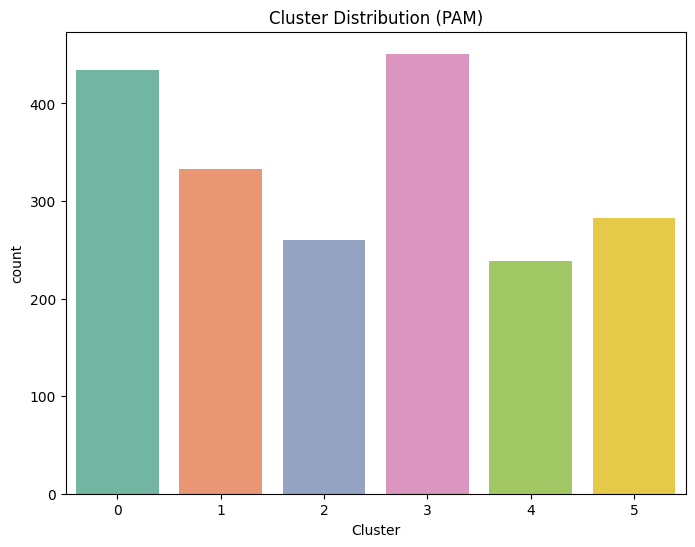

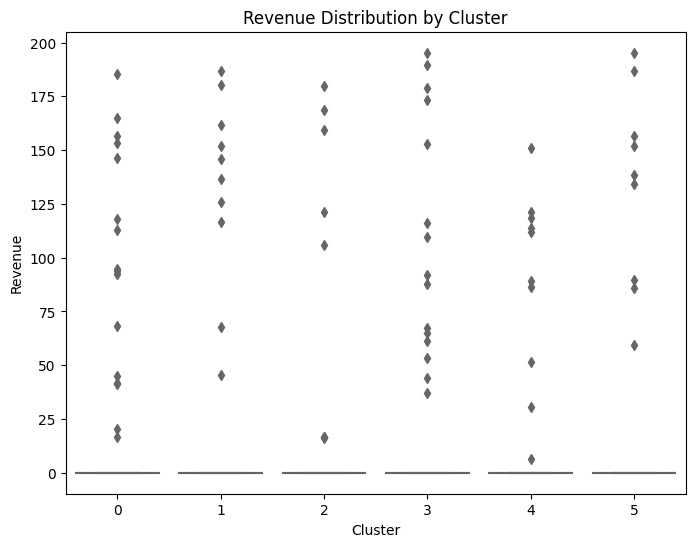

In [ ]:
# =======================================
# 📘 PART B: Existing Model (Paper's PAM Clustering)
# =======================================

# Visualize Cluster Distribution
plt.figure(figsize=(8,6))
sns.countplot(x="Cluster", data=df, palette="Set2")
plt.title("Cluster Distribution (PAM)")
plt.show()

# Revenue per Cluster
plt.figure(figsize=(8,6))
sns.boxplot(x="Cluster", y="Revenue", data=df, palette="Set3")
plt.title("Revenue Distribution by Cluster")
plt.show()


In [ ]:
# =======================================
# 📘 PART C: Proposed Models (Supervised Classification)
# =======================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

results = {}

# Helper function
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"📌 {name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.show()
    return model


c:\Users\ADMIN\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


📌 Logistic Regression Accuracy: 0.8700
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       145
           1       0.88      0.91      0.89        96
           2       0.85      0.79      0.82        81
           3       0.90      0.87      0.88       129
           4       0.92      0.93      0.92        70
           5       0.82      0.89      0.85        79

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600



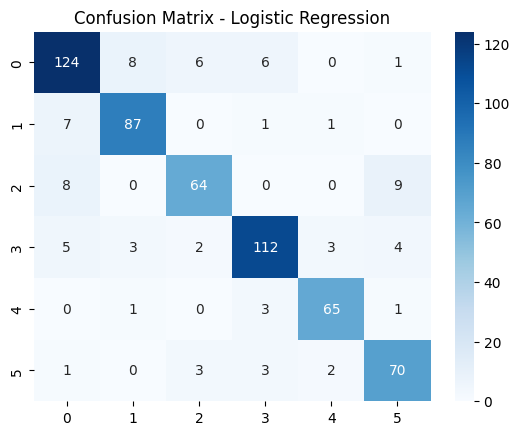

In [ ]:
# Logistic Regression
lr_model = evaluate_model("Logistic Regression", LogisticRegression(max_iter=1000), X_train, X_test, y_train, y_test)


📌 Random Forest Accuracy: 0.9083
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       145
           1       0.88      0.97      0.92        96
           2       0.94      0.83      0.88        81
           3       0.92      0.92      0.92       129
           4       0.90      0.89      0.89        70
           5       0.89      0.92      0.91        79

    accuracy                           0.91       600
   macro avg       0.91      0.91      0.91       600
weighted avg       0.91      0.91      0.91       600



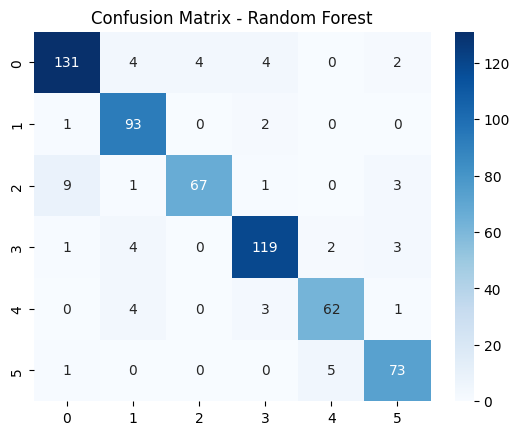

In [ ]:
# Random Forest
rf_model = evaluate_model("Random Forest", RandomForestClassifier(n_estimators=200, random_state=42), X_train, X_test, y_train, y_test)


📌 Gradient Boosting Accuracy: 0.9433
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       145
           1       0.98      0.91      0.94        96
           2       0.95      0.93      0.94        81
           3       0.95      0.97      0.96       129
           4       0.91      0.97      0.94        70
           5       0.92      0.96      0.94        79

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



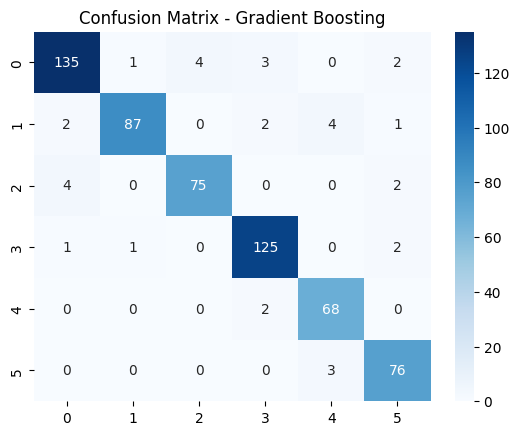

In [ ]:
# Gradient Boosting
gb_model = evaluate_model("Gradient Boosting", GradientBoostingClassifier(), X_train, X_test, y_train, y_test)


📌 SVM Accuracy: 0.8383
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       145
           1       0.86      0.89      0.87        96
           2       0.88      0.60      0.72        81
           3       0.83      0.94      0.88       129
           4       0.84      0.84      0.84        70
           5       0.73      0.76      0.75        79

    accuracy                           0.84       600
   macro avg       0.84      0.82      0.82       600
weighted avg       0.84      0.84      0.84       600



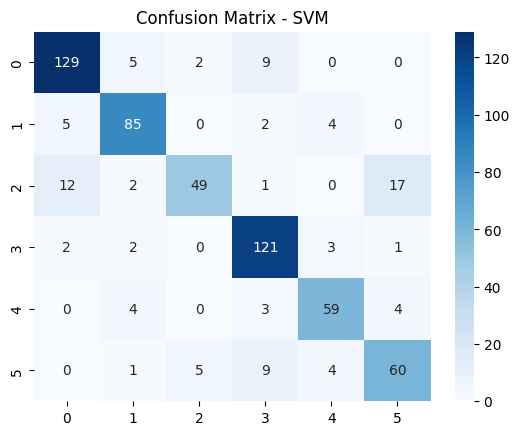

In [ ]:
# Support Vector Machine
svm_model = evaluate_model("SVM", SVC(), X_train, X_test, y_train, y_test)


📌 Neural Network Accuracy: 0.8700
              precision    recall  f1-score   support

           0       0.89      0.86      0.87       145
           1       0.90      0.83      0.86        96
           2       0.81      0.85      0.83        81
           3       0.88      0.93      0.91       129
           4       0.88      0.91      0.90        70
           5       0.84      0.81      0.83        79

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600



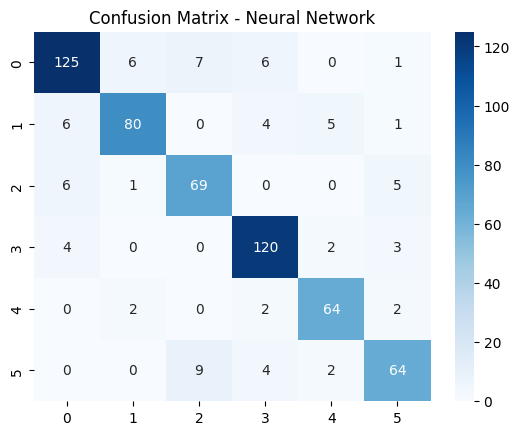

In [ ]:
# Neural Network
nn_model = evaluate_model("Neural Network", MLPClassifier(hidden_layer_sizes=(64,32), max_iter=500, random_state=42), X_train, X_test, y_train, y_test)


                 Model  Accuracy
0  Logistic Regression  0.870000
1        Random Forest  0.908333
2    Gradient Boosting  0.943333
3                  SVM  0.838333
4       Neural Network  0.870000


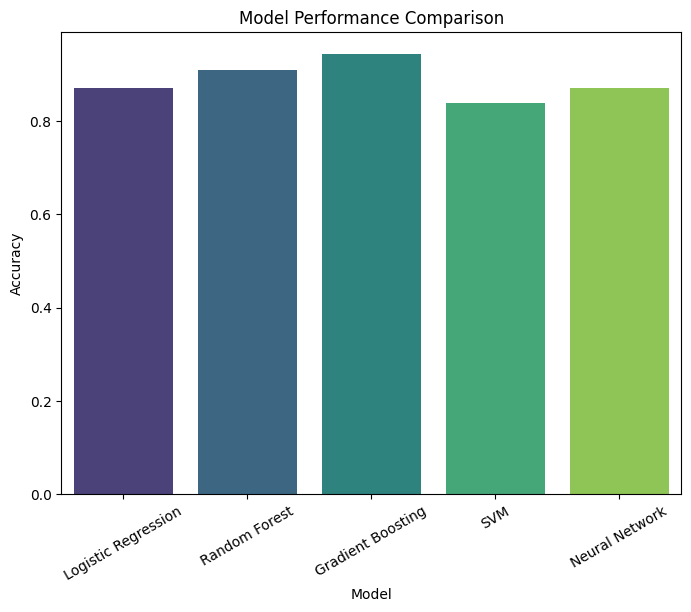

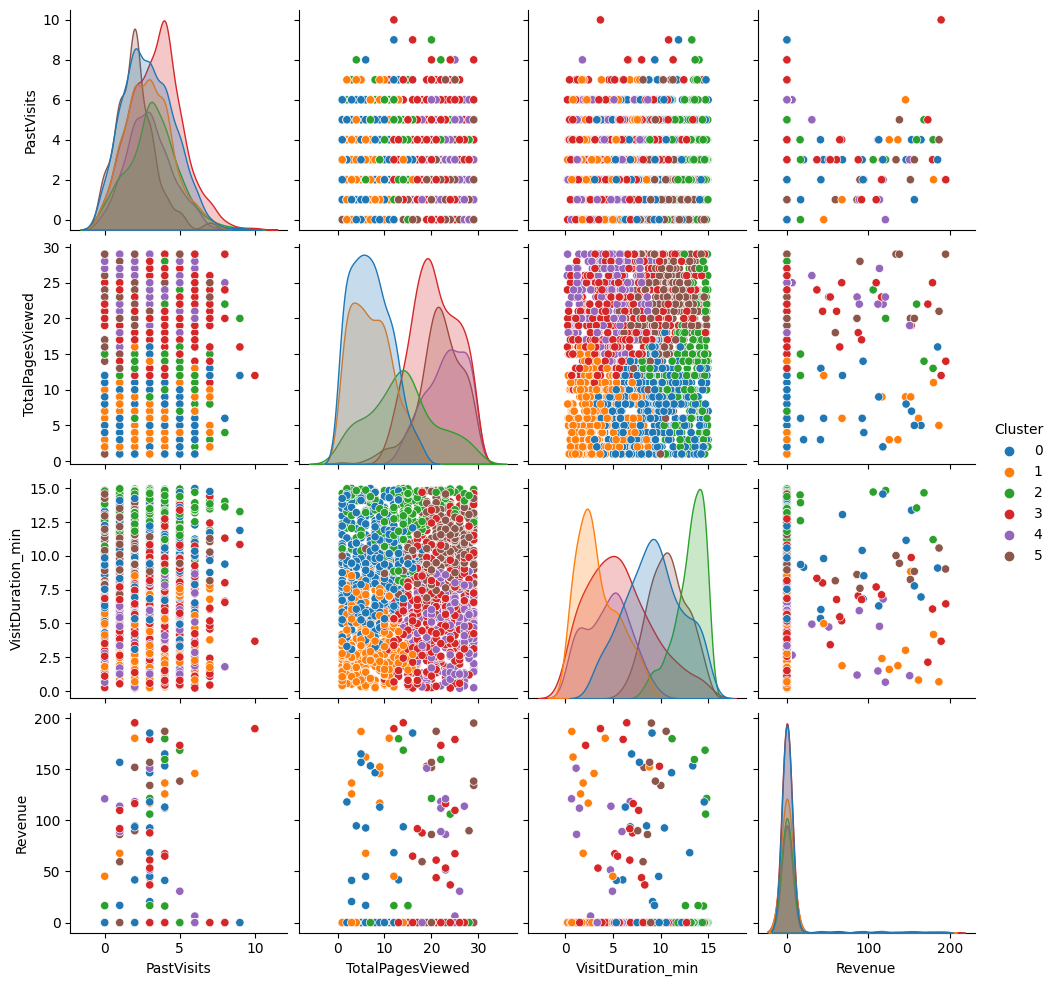

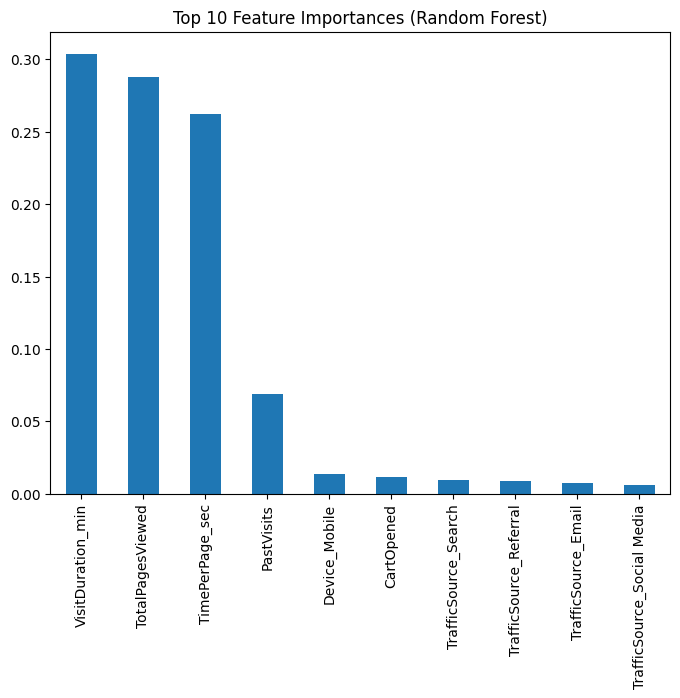

In [ ]:
# =======================================
# 📘 PART D: Accuracy Comparison
# =======================================

# Accuracy Table
acc_table = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print(acc_table)

# Accuracy Bar Plot
plt.figure(figsize=(8,6))
sns.barplot(x="Model", y="Accuracy", data=acc_table, palette="viridis")
plt.ylabel("Accuracy")
plt.title("Model Performance Comparison")
plt.xticks(rotation=30)
plt.show()

# EXTRA VISUALIZATION 1: Pairplot of numerical features by cluster
sns.pairplot(df, vars=["PastVisits","TotalPagesViewed","VisitDuration_min","Revenue"], hue="Cluster", palette="tab10")
plt.show()

# EXTRA VISUALIZATION 2: Feature importance (Random Forest)
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)[:10]
feat_imp.plot(kind="bar", figsize=(8,6), title="Top 10 Feature Importances (Random Forest)")
plt.show()


In [ ]:
import joblib

# Save best model (Random Forest as example)
joblib.dump(gb_model, "best_model.pkl")
print("✅ Model saved as best_model.pkl")

✅ Model saved as best_model.pkl


In [ ]:
# =======================================
# 📘 PART E: Save & Load Model with Custom Input
# =======================================

import pandas as pd
import joblib

# Load model
loaded_model = joblib.load("best_model.pkl")

# Custom Input (simulate one new user session)
custom_input = {
    "Device": "laptop",
    "TrafficSource": "Buy",
    "PastVisits": 1,
    "TotalPagesViewed": 20,
    "TimePerPage_sec": 30.3,
    "VisitDuration_min": 10.2,
    "CartOpened": 5,
    "PurchaseMade": 0,
    "Revenue": 100.0
}

# Convert to DataFrame
custom_df = pd.DataFrame([custom_input])

# One-hot encode like training data
custom_encoded = pd.get_dummies(custom_df)
custom_encoded = custom_encoded.reindex(columns=X_train.columns, fill_value=0)

# Predict cluster
pred_cluster = loaded_model.predict(custom_encoded)[0]

# Map cluster number to descriptive name
cluster_names = {
    0: "Mobile Window Shopping – largest, low revenue.",
    1: "Enticed to Buy – smaller, high revenue.",
    2: "Examining an Offer – email-driven, low purchases.",
    3: "Online Window Shopping – desktop, low purchases.",
    4: "Visiting with a Purpose – very small, but highest revenue.",
    5: "Impulsive Trying – social media-driven, medium revenue."
}

pred_name = cluster_names.get(pred_cluster, "Unknown Cluster")

print("🔮 Predicted Consumer Segment:", pred_name)


🔮 Predicted Consumer Segment: Impulsive Trying – social media-driven, medium revenue.


In [ ]:
!pip freeze > req.txt